# Градиентный спуск

В этом практическом занятии вы реализуете градиентный спуск самостоятельно. На сегодняшний день -- это основной способ оптимизации нейронных сетей.

Мы начнем с простой функции -- парабола, затем перейдем к чуть более сложной.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

**Задание 1**

Закончите реализацию алгоритма градиентного спуска.

In [13]:
def gradient_descent(f: callable, df_dx: callable, initial_position: float, n_iters: int, lr: float,
                     tol: float = 1e-3):
    """
    Алгоритм градиентного спуска.

    f -- функция, минимум которой мы хотим найти
    df_dx -- производная функции по x
    initial_position -- начальное приближение
    n_iters -- максимальное количество шагов градиентного спуска
    lr -- learning rate, скорость обучения
    tol -- точность с которой мы будем считать, что значение функции не меняется

    Функция должна вернуть найденный минимум, историю положений
    и значений функции
    """
    positions = []
    values = []
    position_old = initial_position
    for i in range(n_iters):
        positions.append(position_old)
        values.append(f(position_old))
        
        # < YOUR CODE STARTS HERE >
        # Реализуйте шаг градиентного спуска.
        position = position_old - lr * df_dx(position_old)
        # < YOUR CODE ENDS HERE >
        if i > 0 and abs(f(position) - values[-1]) < tol:  #после первого шага проверям . нужен ли следующий ход
                position_old = position
                positions.append(position_old)
                values.append(f(position_old))
                break
        
        position_old = position
            
    print(f"Found minimum at x={position_old} after {len(positions) - 1} steps.")
    return position_old, positions, values

def visualize(f: callable, limits: tuple, positions: list, values: list):
    xs = np.linspace(limits[0], limits[1], 100)
    plt.figure(figsize=(10, 5))
    plt.plot(xs, f(xs))
    plt.title(f"Найденный минимум после {len(positions) - 1} шагов: $f = {values[-1]:.2}$ при $x = {positions[-1]:.2}$")
    _, = plt.plot(positions, values)
    for p, v in zip(positions, values):
        plt.scatter(p, v, s=30, zorder=4)

In [18]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

# Исходная функция
def f(x):
    return np.exp(-x) * np.sin(x)

# 1. Ваша функция численного дифференцирования
def numerical_derivative(f, x, h=1e-5):
    """Численная производная (метод конечных разностей)"""
    return (f(x + h) - f(x - h)) / (2*h)

# 2. Аналитическая производная (выведенная выше)
def df_dx_analytic(x):
    return np.exp(-x) * (np.cos(x) - np.sin(x))

# 3. Символьное вычисление с помощью SymPy
x_sym = sp.symbols('x')
f_sym = sp.exp(-x_sym) * sp.sin(x_sym)
df_dx_sym = sp.diff(f_sym, x_sym)
# Преобразуем символьное выражение в функцию для вычислений
df_dx_sym_func = sp.lambdify(x_sym, df_dx_sym, 'numpy')

# Точка для сравнения
x_point = 0.5
h = 1e-5

# Вычисляем производные
num_deriv = numerical_derivative(f, x_point, h)
sym_deriv = df_dx_sym_func(x_point)
ana_deriv = df_dx_analytic(x_point)

# Вывод результатов
print("Результаты в точке x =", x_point)
print(f"Численный метод (h={h}): {num_deriv}")
print(f"Библиотека SymPy: {sym_deriv}")
print(f"Аналитическая формула: {ana_deriv}")
print(f"Разница между SymPy и численным методом: {abs(sym_deriv - num_deriv)}")

Результаты в точке x = 0.5
Численный метод (h=1e-05): 0.24149444202981038
Библиотека SymPy: 0.24149444200297893
Аналитическая формула: 0.2414944420029789
Разница между SymPy и численным методом: 2.683145372550655e-11


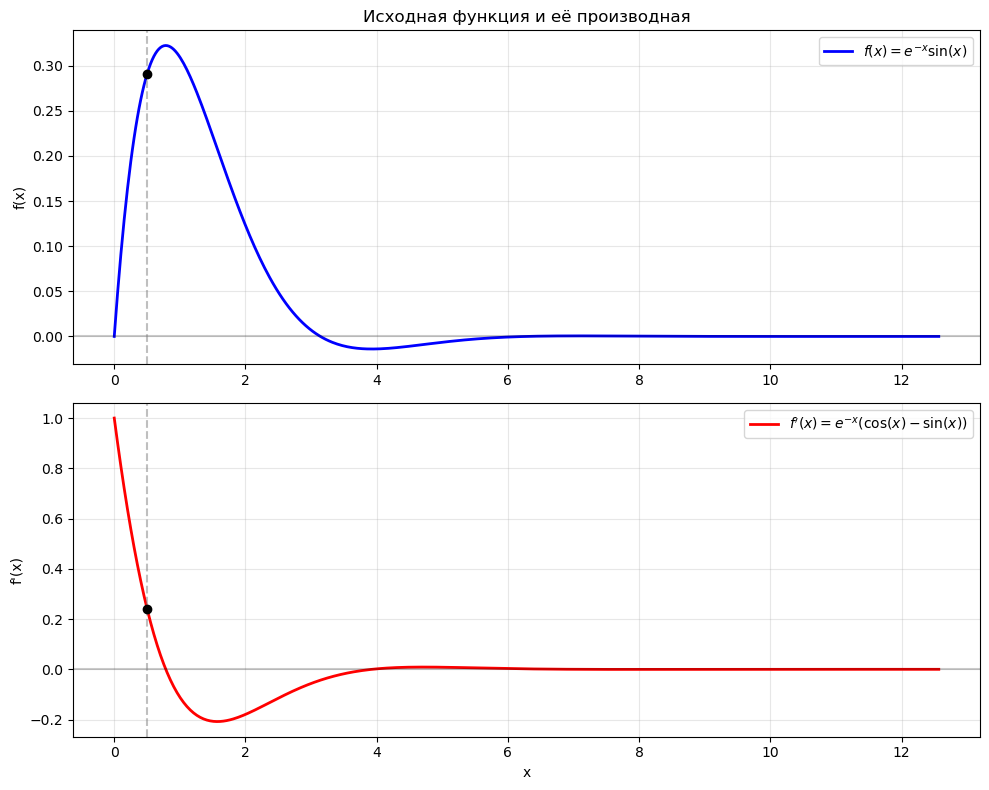

In [2]:
# Создаем массив точек для построения графика
x_vals = np.linspace(0, 4*np.pi, 500) # От 0 до 4π
y_vals = f(x_vals)

# Вычисляем производную через аналитическую формулу
y_deriv_vals = df_dx_analytic(x_vals)

# Построение графика
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# График исходной функции
ax1.plot(x_vals, y_vals, 'b-', linewidth=2, label=r'$f(x) = e^{-x} \sin(x)$')
ax1.set_ylabel('f(x)')
ax1.set_title('Исходная функция и её производная')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axhline(y=0, color='k', linestyle='-', alpha=0.2)

# График производной
ax2.plot(x_vals, y_deriv_vals, 'r-', linewidth=2, label=r"$f'(x) = e^{-x}(\cos(x) - \sin(x))$")
ax2.set_xlabel('x')
ax2.set_ylabel("f'(x)")
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.2)

# Отметим точку x=0.5
for ax in [ax1, ax2]:
    ax.axvline(x=x_point, color='gray', linestyle='--', alpha=0.5)
    ax.plot(x_point, f(x_point) if ax == ax1 else df_dx_analytic(x_point), 'ko')

plt.tight_layout()
plt.show()

Found minimum at x=-0.50229376 after 8 steps.


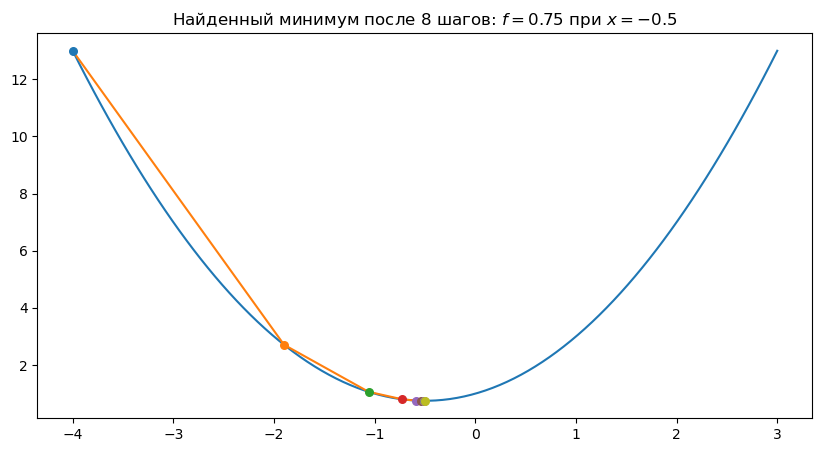

In [19]:
f = lambda x: x**2 + x + 1 # функция для оптимизации
df_dx = lambda x: 2*x + 1 # производная

lr = 0.3
n_iters = 20
initial_position = -4.


position, positions, values = gradient_descent(f=f, df_dx=df_dx, initial_position=initial_position,
                                               n_iters=n_iters, lr=lr, tol=1e-4)

visualize(f, (-4, 3), positions=positions, values=values)

Производная: (2*x - 4)*(x**2 + 4*x + 2) + (2*x + 4)*(x**2 - 4*x + 4)
Found minimum at x=-2.4201157978635264 after 95 steps.


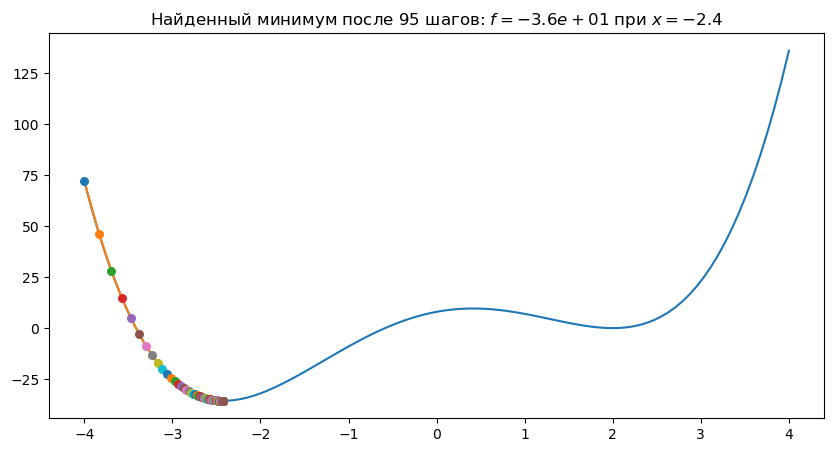

In [26]:
import sympy as sp
# градиентный спуск
initial_position = -4
f = lambda x: (x**2 - 4*x + 4)*(x**2 + 4*x + 2)
#опрееделяем символьную переменную
x = sp.symbols('x')
#создаем символьное выражение функции
f_expr = (x**2 - 4*x + 4)*(x**2 + 4*x + 2)

# < YOUR CODE STARTS HERE>
# Напишите, чему равна производная f по x
df_dx = sp.diff(f_expr, x)
# < YOUR CODE ENDS HERE>
print(f"Производная: {df_dx}")
# < YOUR CODE STARTS HERE>
# Выберите подходящие параметры для оптимизации
#преобразуем символьные выражения в функции для вычислений
f = sp.lambdify(x, f_expr, 'numpy')
df_dx = sp.lambdify(x, df_dx, 'numpy')

n_iters = 200
lr = 0.001
# < YOUR CODE ENDS HERE>


position, positions, values = gradient_descent(f=f, df_dx=df_dx, initial_position=initial_position,
                                               n_iters=n_iters, lr=lr, tol=1e-4)
visualize(f, (-4, 4), positions=positions, values=values)

**Задание 2**
Продемонстрируйте на примере функции выше:
1. застревание в локальном минимуме (выберете другое начальное приближение)
2. расхождение оптимизации (попробуйте другую скорость обучения)

Скопируйте код из клетки выше в две последующие и оставьте графики для оценки и демонстрации.

Производная: (2*x - 4)*(x**2 + 4*x + 2) + (2*x + 4)*(x**2 - 4*x + 4)
Found minimum at x=2.0108798855574634 after 136 steps.


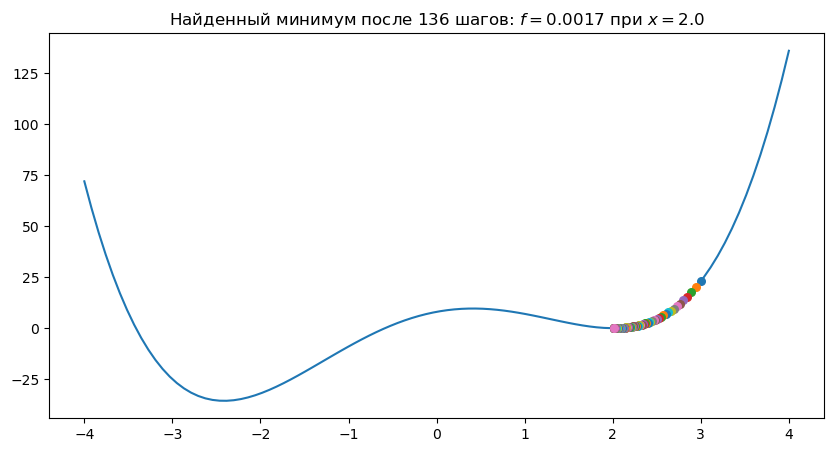

In [28]:
# Задание 2.1

# градиентный спуск
initial_position = 3
f = lambda x: (x**2 - 4*x + 4)*(x**2 + 4*x + 2)

#опрееделяем символьную переменную
x = sp.symbols('x')
#создаем символьное выражение функции
f_expr = (x**2 - 4*x + 4)*(x**2 + 4*x + 2)

# < YOUR CODE STARTS HERE>
# Напишите, чему равна производная f по x
df_dx = sp.diff(f_expr, x)
# < YOUR CODE ENDS HERE>
print(f"Производная: {df_dx}")
# < YOUR CODE STARTS HERE>
#преобразуем символьные выражения в функции для вычислений
f = sp.lambdify(x, f_expr, 'numpy')
df_dx = sp.lambdify(x, df_dx, 'numpy')

# Выберите подходящие параметры для оптимизации
n_iters = 200
lr = 0.001
# < YOUR CODE ENDS HERE>


position, positions, values = gradient_descent(f=f, df_dx=df_dx, initial_position=initial_position,
                                               n_iters=n_iters, lr=lr, tol=1e-4)
visualize(f, (-4, 4), positions=positions, values=values)

Производная: (2*x - 4)*(x**2 + 4*x + 2) + (2*x + 4)*(x**2 - 4*x + 4)
Found minimum at x=-2.4081623389090026 after 197 steps.


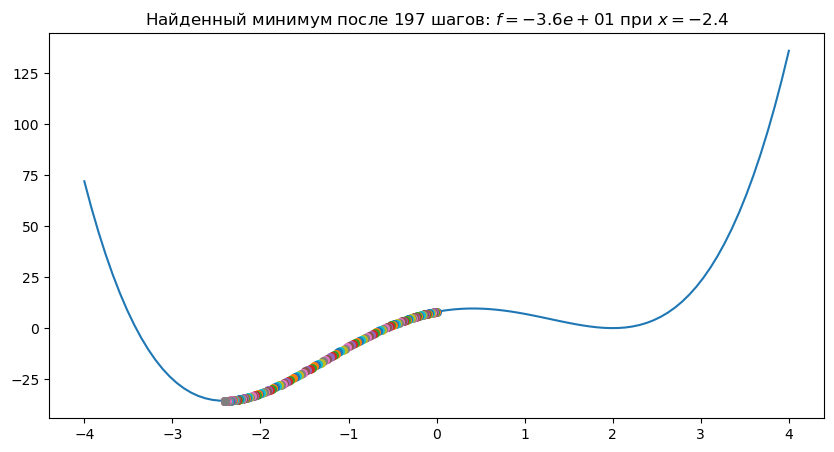

In [29]:
# Задание 2.1

# градиентный спуск
initial_position = 0
f = lambda x: (x**2 - 4*x + 4)*(x**2 + 4*x + 2)

#опрееделяем символьную переменную
x = sp.symbols('x')
#создаем символьное выражение функции
f_expr = (x**2 - 4*x + 4)*(x**2 + 4*x + 2)

# < YOUR CODE STARTS HERE>
# Напишите, чему равна производная f по x
df_dx = sp.diff(f_expr, x)
# < YOUR CODE ENDS HERE>
print(f"Производная: {df_dx}")
# < YOUR CODE STARTS HERE>
#преобразуем символьные выражения в функции для вычислений
f = sp.lambdify(x, f_expr, 'numpy')
df_dx = sp.lambdify(x, df_dx, 'numpy')

# Выберите подходящие параметры для оптимизации
n_iters = 200
lr = 0.001
# < YOUR CODE ENDS HERE>


position, positions, values = gradient_descent(f=f, df_dx=df_dx, initial_position=initial_position,
                                               n_iters=n_iters, lr=lr, tol=1e-4)
visualize(f, (-4, 4), positions=positions, values=values)